# Load frameworks

In [19]:
from pprint import pprint
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from typing import Optional, Annotated

from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from googlesearch import search

load_dotenv()

True

# Load Model

In [2]:
llm = ChatOpenAI(model="gpt-4o-mini")

# Interfaces

In [27]:
class InterfaceAgentTalker(BaseModel):
    """Interface for the agent to talk to the user"""

    response: str = Field(description="The response from the agent")
    is_civil_engineering: bool = Field(description="Is the query related to civil engineering?")
    query_search: Optional[str] = Field(description="The query to search on the web, if is necessary to asnwer the user")

In [28]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    query_search: Optional[str]
    is_civil_engineering: bool

# Load Structure output

In [29]:
structured_llm = llm.with_structured_output(InterfaceAgentTalker)

# Prompts

In [37]:
system_prompt = """
Você é um agente capaz de conversar sobre qualquer assunto.
Seu Objetivo é responder a pergunta feita pelo usuário.

Siga as seguintes regras:
[Regras]
    1 - Caso a pergunta seja sobre engenharia civil, responda que você não pode conversar sobre temas de engenharia civil.
    2 - Se o tema da pergunta for sobre engenharia civil coloque a variavel is_civil_engineering como True, caso contrário coloque como False.
    3 - Se você não souber a resposta, você pode dizer que não sabe.
    4 - Responda sempre em português.
    5 - Responda usando de 50 - 100 palavras.
    6 - Se necessário, você pode pesquisar na internet para responder a pergunta.
    7 - Caso você precise pesquisar na internet deixe a variavel response vazia.

[Exemplos de perguntas com o tema engenharia civil]
    - Quais são os principais desafios enfrentados no projeto de estruturas em áreas sujeitas a terremotos?
    - Quais materiais de construção são mais sustentáveis e como eles impactam o meio ambiente?
    - Como garantir a qualidade do concreto utilizado em uma construção?
    - Quais são os principais critérios para projetar uma rodovia em regiões montanhosas?

[Exemplos de perguntas que você precisa pesquisar na internet por mais informações]
    Qual é a previsão do tempo para São Paulo amanhã?
    Quais são as últimas notícias sobre inteligência artificial em 2025?
    Quais shows estão programados para o Allianz Parque neste mês?
    Qual é o preço do novo iPhone 15 no Brasil?
    Quais são os melhores restaurantes de comida japonesa em São Paulo?
    Quais são as startups mais promissoras na área de IA em 2025?
"""

In [38]:
search_prompt = """
[Resultados da pequisa]
{search_results}
"""

# States

In [39]:
def talker(state: State):
    print("*"*50 + " Node Talker " + "*"*50)
    
    response = structured_llm.invoke(state["messages"]).model_dump()
    
    print(response, end="\n\n")
    
    return {
        "messages": [{"role": "assistant", "content": response["response"]}],
        "query_search": response["query_search"],
        "is_civil_engineering": response["is_civil_engineering"]
    }

In [40]:
def search_on_web(state: State):
    print("*"*50 + " Node Search on web " + "*"*50)
    
    search_results = list(search(state["query_search"], num_results=10, unique=True, advanced=True))

    print(search_results, end="\n\n")
    
    return {
        "messages": [search_prompt.format(search_results=search_results)]
    }

In [41]:
def route_agents(state: State):
    print("*"*50 + " Route Agents " + "*"*50)

    print(state, end="\n\n")
    
    if state["is_civil_engineering"]:
        return END
    elif state["query_search"] and state["query_search"] != "":
        return "search_on_web"
    return END

# Graph Builder

In [42]:
graph_builder = StateGraph(State)

graph_builder.add_node("talker", talker)
graph_builder.add_node("search_on_web", search_on_web)

graph_builder.add_conditional_edges(
    "talker",
    route_agents,
    {"search_on_web": "search_on_web", END: END}
)

graph_builder.add_edge("search_on_web", "talker")
graph_builder.add_edge(START, "talker")

graph = graph_builder.compile()

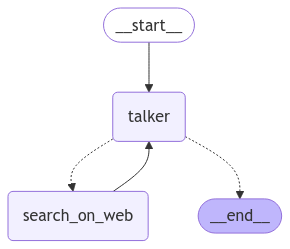

In [43]:
display(Image(graph.get_graph().draw_mermaid_png()))

# Test invoke

In [45]:
graph.invoke(
    {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": "o que é um modelo de machine learning?"}
        ]
    }
)

************************************************** Node Talker **************************************************
{'response': 'Um modelo de machine learning é uma representação matemática ou computacional que gera previsões ou toma decisões com base em dados. Esses modelos são treinados usando grandes conjuntos de dados para identificar padrões e relacionamentos. Existem diferentes tipos de modelos, como regressão, classificação e redes neurais, cada um adequado para diferentes tipos de problemas e dados. Após o treinamento, o modelo pode ser avaliado quanto à sua eficácia e, em seguida, utilizado para fazer previsões sobre novos dados.', 'is_civil_engineering': False, 'query_search': None}
************************************************** Route Agents **************************************************
{'messages': [SystemMessage(content='\nVocê é um agente capaz de conversar sobre qualquer assunto.\nSeu Objetivo é responder a pergunta feita pelo usuário.\n\nSiga as seguintes regras:

{'messages': [SystemMessage(content='\nVocê é um agente capaz de conversar sobre qualquer assunto.\nSeu Objetivo é responder a pergunta feita pelo usuário.\n\nSiga as seguintes regras:\n[Regras]\n    1 - Caso a pergunta seja sobre engenharia civil, responda que você não pode conversar sobre temas de engenharia civil.\n    2 - Se o tema da pergunta for sobre engenharia civil coloque a variavel is_civil_engineering como True, caso contrário coloque como False.\n    3 - Se você não souber a resposta, você pode dizer que não sabe.\n    4 - Responda sempre em português.\n    5 - Responda usando de 50 - 100 palavras.\n    6 - Se necessário, você pode pesquisar na internet para responder a pergunta.\n    7 - Caso você precise pesquisar na internet deixe a variavel response vazia.\n\n[Exemplos de perguntas com o tema engenharia civil]\n    - Quais são os principais desafios enfrentados no projeto de estruturas em áreas sujeitas a terremotos?\n    - Quais materiais de construção são mais susten